# [SOLUTIONS] Lab 1 — Neural Architecture Search on HW-NAS-Bench

## Search space, estimation strategy, and simple search algorithms

In this lab, we will work with a tabular benchmark: a CSV file extracted from [NAS-Bench-201](https://openreview.net/forum?id=HJxyZkBKDr$0) search space, the accuracy obtained after training.

Having a tabular benchmark means that "training and evaluating" a network costs a table lookup: we can therefore compare search algorithms in a few seconds, repeating experiments across many seeds, which would be impossible if we had to actually train every network.

Lab objectives

1. Understand how a cell-based search space is structured and how an architecture is encoded.
2. Separate the three components of a NAS system: search space, search strategy, performance estimation strategy.
3. Implement and compare Grid Search, Random Search, and Bayesian Optimization.


## 0. Setup

In [1]:
import itertools
import time
import warnings
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

REPO_URL = "https://raw.githubusercontent.com/bizzarriA/NAS-lab/main"
if not os.path.exists("utils.py"):
    urllib.request.urlretrieve(f"{REPO_URL}/utils.py", "utils.py")
from utils import OPS, EDGES, load_benchmark, draw_cell, Oracle, make_gp, plot_regret

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1. Data loading



The benchmark is downloaded automatically. `load_benchmark` returns a table with **one row per architecture** (15625 in total) and always the same columns, whatever dataset and device you choose:

| column | meaning |
| --- | --- |
| `arch_str` | architecture string in NAS-Bench-201 format |
| `op_e1_0` … `op_e3_2` | operation on each edge (`op_eJ_I` = edge from node I to node J) |
| `ops` | the same 6 operations as a tuple, handy for the search algorithms |
| `acc` | **validation** accuracy (%) after 200 epochs: this is what we optimize |
| `test_acc` | test accuracy (%): use it only to report the final result |
| `lat`, `energy` | latency (ms) and energy (mJ) on the chosen device |
| `cost` | training time (s), used to simulate the search cost |
| `flops`, `params` | FLOPs (M) and parameters (M) |

You can change `DATASET` and `DEVICE`. Not all devices provide every metric: energy is available only for `edgegpu`, `eyeriss` and `fpga` (otherwise the column is empty).

In [2]:
DATA_PATH = f"hw_nasbench201.csv.gz"   # or a local path
if not os.path.exists(DATA_PATH):
    urllib.request.urlretrieve(f"{REPO_URL}/{DATA_PATH}", f"{DATA_PATH}")


DATASET = "cifar100"   # cifar10 | cifar100 | imagenet16

df = load_benchmark(DATA_PATH, dataset=DATASET)

N_ARCH = len(df)
ARCH2IDX = {ops: i for i, ops in enumerate(df["ops"])}   # tuple of ops -> row index
BEST_ACC = df["acc"].max()                               # best accuracy in the whole space
df.head()

Loaded 15625 architectures | dataset = cifar100 


,arch_str,op_e1_0,op_e2_0,op_e2_1,op_e3_0,op_e3_1,op_e3_2,ops,acc,test_acc,cost
0,|avg_pool_3x3~0|+|nor_conv_1x1~0|skip_connect~...,avg_pool_3x3,nor_conv_1x1,skip_connect,nor_conv_1x1,skip_connect,skip_connect,"(avg_pool_3x3, nor_conv_1x1, skip_connect, nor...",52.7000,52.9133,2888.4372
1,|nor_conv_3x3~0|+|nor_conv_3x3~0|avg_pool_3x3~...,nor_conv_3x3,nor_conv_3x3,avg_pool_3x3,skip_connect,nor_conv_3x3,skip_connect,"(nor_conv_3x3, nor_conv_3x3, avg_pool_3x3, ski...",69.8267,70.2933,4339.2828
2,|avg_pool_3x3~0|+|nor_conv_3x3~0|nor_conv_3x3~...,avg_pool_3x3,nor_conv_3x3,nor_conv_3x3,avg_pool_3x3,avg_pool_3x3,avg_pool_3x3,"(avg_pool_3x3, nor_conv_3x3, nor_conv_3x3, avg...",54.3000,54.8667,4534.3554
3,|avg_pool_3x3~0|+|skip_connect~0|none~1|+|none...,avg_pool_3x3,skip_connect,none,none,none,skip_connect,"(avg_pool_3x3, skip_connect, none, none, none,...",57.4133,58.3067,1666.0980
4,|skip_connect~0|+|skip_connect~0|nor_conv_1x1~...,skip_connect,skip_connect,nor_conv_1x1,skip_connect,skip_connect,nor_conv_1x1,"(skip_connect, skip_connect, nor_conv_1x1, ski...",59.5667,60.1400,2593.7196


## 2. Benchmark exploration



Before searching, let's look at the data: how are the accuracies distributed? How much does an accurate network cost (in latency)?

             acc   test_acc       cost
count  15625.000  15625.000  15625.000
mean      61.300     61.406   3655.974
std       12.142     12.172    943.338
min        1.000      1.000   1084.462
25%       59.060     59.240   2978.400
50%       65.167     65.287   3634.250
75%       67.740     67.880   4317.074
max       73.493     73.513   6921.663


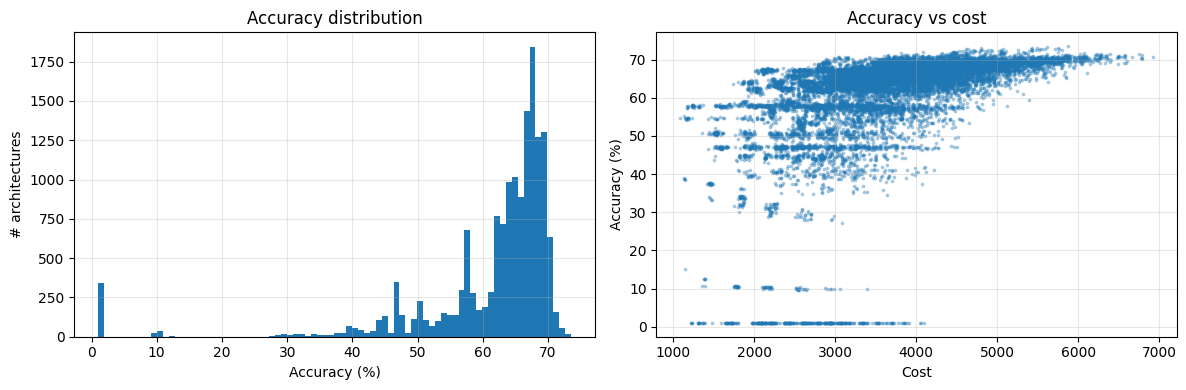

Best architecture: |nor_conv_3x3~0|+|nor_conv_3x3~0|nor_conv_3x3~1|+|skip_connect~0|nor_conv_3x3~1|nor_conv_3x3~2| → 73.49%
99th percentile of accuracy: 71.03


In [3]:
print(df[["acc", "test_acc", "cost"]].describe().round(3))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(df["acc"], bins=80, color="tab:blue")
ax[0].set(xlabel="Accuracy (%)", ylabel="# architectures", title="Accuracy distribution")
ax[1].scatter(df["cost"], df["acc"], s=3, alpha=0.3)
ax[1].set(xlabel=f"Cost", ylabel="Accuracy (%)", title="Accuracy vs cost")
plt.tight_layout(); plt.show()

best = df.loc[df["acc"].idxmax()]
print("Best architecture:", best["arch_str"], f"→ {best['acc']:.2f}%")
print("99th percentile of accuracy:", np.percentile(df["acc"], 99).round(2))

### Questions — NAS vs Hyperparameter tuning

Some questions?

## 3. The search space: cell-based design



In NAS-Bench-201, the network consists of a fixed skeleton (stem, 3 stages of stacked cells, reduction blocks between stages, classifier). Search concerns only the cell, which is then repeated.

The cell is a DAG with 4 nodes (0 = input, 3 = output). Each pair of nodes $i<j$ is connected by an edge, for a total of 6 edges, and on each edge one operation is chosen from:

| operation | meaning |
| --- | --- |
| `none` | absent edge (zero) |
| `skip_connect` | identity |
| `nor_conv_1x1` | ReLU-Conv1x1-BN |
| `nor_conv_3x3` | ReLU-Conv3x3-BN |
| `avg_pool_3x3` | 3x3 average pooling |

Each node sums the contributions of incoming edges.

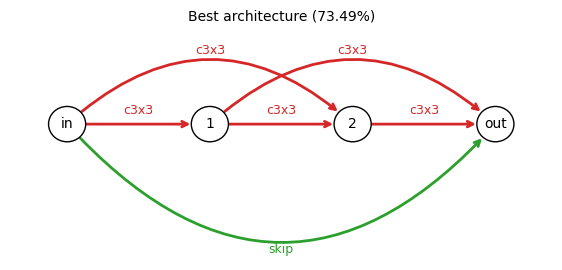

<Axes: title={'center': 'Best architecture (73.49%)'}>

In [4]:
draw_cell(best, title=f"Best architecture ({best['acc']:.2f}%)")

### Exercise 1 — Search space analysis

**1a.** Calculate analytically the cardinality of the search space (hint: use $n_{OPS}^{n_{EDGES}}$) and compare it with the number of rows in the CSV.

**1b.** Some cells do not connect the input to the output (all paths contain a `none` edge): whatever the rest of the network is, the cell produces zero. Complete the `is_connected` function and count how many there are. What accuracy do they have in the benchmark?

<details>
<summary>💡 Hint</summary>

First, build a list of 6 booleans, one per edge, that is `True` if the edge exists (i.e. its operation is not `none`). For example, for the operations `("nor_conv_3x3", "none", "skip_connect", "none", "none", "avg_pool_3x3")` the list is `[True, False, True, False, False, True]`.

Then work node by node, in order, and ask: *can node k receive anything from the input?*

- Node 1 is reachable if its only incoming edge (from node 0) exists.
- Node 2 is reachable if the edge 0→2 exists, **or** if the edge 1→2 exists **and** node 1 is reachable.
- Apply the same idea to node 3: the cell is connected if node 3 is reachable.

Remember the edge order in `EDGES`: `(1,0), (2,0), (2,1), (3,0), (3,1), (3,2)`.
</details>

In [5]:
# 1a
space_size = len(OPS) ** len(EDGES)
print("Theoretical cardinality:", space_size, "| row in the CSV:", N_ARCH)

Theoretical cardinality: 15625 | row in the CSV: 15625


Unconnected cells: 341
             count   mean   std  min    25%   50%    75%    max
connected                                                      
False        341.0   1.00  0.00  1.0   1.00   1.0   1.00   1.00
True       15284.0  62.65  8.23  9.6  60.43  65.3  67.79  73.49
                                              arch_str  acc
10   |nor_conv_3x3~0|+|nor_conv_3x3~0|nor_conv_3x3~...  1.0
12   |none~0|+|none~0|none~1|+|none~0|nor_conv_3x3~...  1.0
74   |nor_conv_3x3~0|+|none~0|none~1|+|none~0|none~...  1.0
104  |none~0|+|avg_pool_3x3~0|nor_conv_1x1~1|+|none...  1.0
105  |none~0|+|none~0|none~1|+|none~0|none~1|avg_po...  1.0


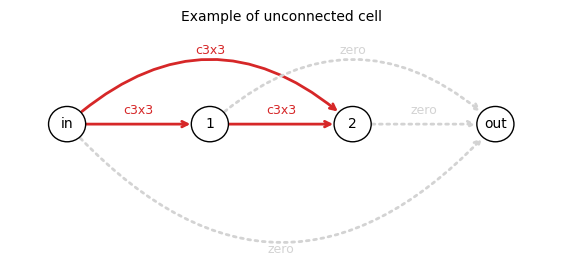

<Axes: title={'center': 'Example of unconnected cell'}>

In [6]:
# 1b
def is_connected(row):
    # return True if the cell is connected (input → output)
    ops =[]
    for dst, src in EDGES:
        ops.append(row[f"op_e{dst}_{src}"])
    e = [o != "none" for o in ops]
    reach1 = e[0]
    reach2 = e[1] or (e[2] and reach1)
    reach3 = e[3] or (e[4] and reach1) or (e[5] and reach2)
    return bool(reach3)

df["connected"] = [is_connected(row) for _, row in df.iterrows()]
print("Unconnected cells:", (~df["connected"]).sum())
print(df.groupby("connected")["acc"].describe().round(2))
print(df[~df["connected"]][["arch_str", "acc"]].head())
draw_cell(df[~df["connected"]].iloc[0], title="Example of unconnected cell")

## 4. Components of NAS



```
 ┌────────────────┐   Architecture  ┌───────────────────────────────┐
 │ Search strategy│ ───────────────▶│ Performance estimation        │
 │  (GS, RS, BO,  │                 │ strategy (qui: lookup nel     │
 │   RL, EA, ...) │ ◀───────────────│ benchmark = complete training)│
 └────────────────┘    Evaluation   └───────────────────────────────┘
          │ samples from
          ▼
 ┌────────────────┐
 │  Search space  │  (cell NB201: 5^6 architectures)
 └────────────────┘
```

In our case, the estimation strategy is an oracle: it returns the final accuracy as if we had trained the network. To make the comparison fair, the oracle:

* counts queries and enforces a budget (maximum number of evaluable architectures);
* accumulates the simulated cost (training time, if present in the CSV);
* can add noise to simulate a low-fidelity estimation (e.g., few epochs).

The oracle is implemented in utils.py. To use it, these methods are sufficient:

|  |  |
| --- | --- |
| Oracle(df, budget, noise_std=0.0, seed=0) | creates the oracle with a query budget |
| oracle.query(idx) | accuracy of the architecture in row idx of df |
| oracle.query_ops(ops) | same, given the tuple of 6 operations |
| oracle.remaining() | queries still available |
| oracle.best() | (ops, accuracy) of the best found so far |
| oracle.incumbent_curve() | best accuracy after each query |

In [7]:
o = Oracle(df, budget=3)
print(o.query(0), o.query(1), o.query(0), "| queries used:", o.n_queries)   # re-query is free
print("Best so far:", o.best())

52.7 69.8267 52.7 | queries used: 2
Best so far: (('nor_conv_3x3', 'nor_conv_3x3', 'avg_pool_3x3', 'skip_connect', 'nor_conv_3x3', 'skip_connect'), 69.8267)


## 5. Grid Search



Grid Search systematically enumerates the Cartesian product of all choices. In NB201 the "full grid" coincides with the whole search space (15625 points): with a budget of 100 evaluations we can see less than 1% of it.

Two typical variants when the budget is limited:
- **truncated full grid**: enumerate in lexicographic order and stop when the budget runs out;
- **reduced grid**: choose a subset of operations for each edge (e.g. 2 choices → $2^6=64$ points).

### EXERCISE 2
Implement `grid_search`. Use `itertools.product`; skip combinations that are not in the dataset; stop when the budget is exhausted.

<details>
<summary>Hint</summary>

**1. Enumerating the grid.** `ops_per_edge` is a list of 6 lists, one per edge, with the operations allowed on that edge. `itertools.product(*ops_per_edge)` yields every possible combination as a tuple of 6 operations, in lexicographic order. The `*` unpacks the list, so each inner list becomes a separate argument. A small example with 2 edges:

    list(itertools.product(["a", "b"], ["x", "y"]))
    # [('a', 'x'), ('a', 'y'), ('b', 'x'), ('b', 'y')]

Notice that the **last** edge changes fastest and the **first** one slowest.

**2. Skipping missing architectures.** Each tuple has the same format as the keys of `ARCH2IDX`. If a tuple is not a key (`ops not in ARCH2IDX`), that architecture is not in the CSV: skip it with `continue`. Skipping does not cost any budget.

**3. Respecting the budget.** Before each query, check `oracle.remaining()`: if it is `0`, stop the loop with `break`. Calling `query` with no budget left raises `BudgetExhausted`.

**4. Evaluating.** Use `oracle.query_ops(ops)`. You don't need to store the result yourself: the oracle keeps the history, and you can read it later with `oracle.best()` and `oracle.incumbent_curve()`.

**5. Returning.** At the end, `return oracle`.

The whole function body is a single `for` loop of about 6 lines.
</details>

In [8]:
def grid_search(oracle, ops_per_edge=None):
    # ops_per_edge: list of 6 lists of allowed operations for each arc
#               (None = all operations on all arcs)
    if ops_per_edge is None:
        ops_per_edge = [OPS] * 6
    for ops in itertools.product(*ops_per_edge):
        if ops not in ARCH2IDX:
            continue
        if oracle.remaining() <= 0:
            break
        oracle.query_ops(ops)
    return oracle


BUDGET = 100
gs_full = grid_search(Oracle(df, BUDGET))
reduced = [["skip_connect", "nor_conv_3x3"]] * 6
gs_red = grid_search(Oracle(df, BUDGET), reduced)
gs_full_rev = grid_search(Oracle(df, BUDGET), [OPS[::-1]] * 6)
for name, o in [("GS complete", gs_full), ("GS complete (inverse order)", gs_full_rev),
                ("GS reduced {skip,c3x3}", gs_red)]:
    ops, acc = o.best()
    print(f"{name:<30} query={o.n_queries:3d}  best={acc:.2f}%  regret={BEST_ACC-acc:.2f}")

GS complete                    query=100  best=67.72%  regret=5.77
GS complete (inverse order)    query=100  best=67.89%  regret=5.60
GS reduced {skip,c3x3}         query= 64  best=73.49%  regret=0.00


### Questions — Grid Search
1. Why does the "truncated complete" grid search depend so heavily on the order of operations? Which edges are actually explored with 100 queries?
2. Does the reduced grid perform well or poorly? What does this depend on? Who selected the grid operations (and based on what prior knowledge)?

## 6. Random Search



Random Search samples architectures uniformly (without repetition) until the budget is exhausted. It is surprisingly competitive and it is the mandatory baseline for any NAS work.

### EXERCISE 3
Implement `random_search` by sampling indices without replacement.

<details>
<summary>Hint</summary>

**1. Working with indices.** Each architecture is a row of `df`, so it is identified by an integer index from `0` to `N_ARCH - 1`. Unlike grid search, you don't need to build tuples of operations: you can sample indices directly and query them with `oracle.query(idx)`.

**2. Sampling without replacement.** The random generator `rng` is already created for you from the `seed`. The simplest way to get indices without repetitions is a random permutation:

    rng.permutation(5)
    # e.g. array([3, 0, 4, 1, 2])

It returns all the numbers from `0` to `n - 1` exactly once, in random order. Iterating over it means sampling uniformly without replacement.

**3. Respecting the budget.** As in grid search, check `oracle.remaining()` before each query and stop with `break` when it reaches `0`.

**4. Returning.** At the end, `return oracle`.

**Why the seed?** Using `rng` (and never `np.random` directly) makes each run reproducible: the same `seed` gives the same sequence of architectures. In Section 8 we will repeat the search with different seeds to average over the randomness.
</details>

In [9]:
def random_search(oracle, seed=0):
    rng = np.random.default_rng(seed)
    for idx in rng.permutation(N_ARCH):
        if oracle.remaining() <= 0:
            break
        oracle.query(idx)
    return oracle


rs = random_search(Oracle(df, BUDGET), seed=0)
print("RS: best = %.2f%%, regret = %.2f" % (rs.best()[1], BEST_ACC - rs.best()[1]))

RS: best = 70.79%, regret = 2.70


### Question
Let $p$ be the fraction of architectures in the top 1% ($p=0.01$). What is the probability that Random Search finds at least one of them within $n$ evaluations? Calculate this for $n=100$ and verify it empirically using the following cell.

In [10]:
thr = np.percentile(df["acc"], 99)
hits = [max(v for _, v in random_search(Oracle(df, BUDGET), seed=s).history) >= thr
        for s in range(200)]
print(f"Empirical: {np.mean(hits):.3f}   Theoretical: {1 - 0.99**BUDGET:.3f}")

Empirical: 0.655   Theoretical: 0.634


## 7. Bayesian Optimization



BO builds a surrogate model (here a Gaussian Process) that predicts the accuracy of architectures not yet evaluated, along with an uncertainty estimate. An acquisition function decides which architecture to evaluate next, balancing exploitation (high mean) and exploration (high uncertainty).

Encoding. The GP works on vectors: we encode each architecture in one-hot (6 edges x 5 operations = 30 dimensions).

Expected Improvement. Given the best observed value $f^*$, mean $\mu(x)$, and standard deviation $\sigma(x)$:

$$z = \frac{\mu(x) - f^* - \xi}{\sigma(x)}, \qquad \mathrm{EI}(x) = (\mu(x) - f^* - \xi)\,\Phi(z) + \sigma(x)\,\varphi(z)$$

where $\Phi$ and $\varphi$ are the CDF and PDF of the standard normal distribution ($\mathrm{EI}=0$ if $\sigma=0$).

Since the search space is small, we can evaluate the acquisition function on all architectures not yet queried and take the maximum.

In [11]:
def encode_onehot(ops):
    v = np.zeros(len(EDGES) * len(OPS))
    for e, op in enumerate(ops):
        v[e * len(OPS) + OPS.index(op)] = 1.0
    return v

X_ALL = np.stack(df["ops"].map(encode_onehot).to_numpy())
print("Coding matrix:", X_ALL.shape)

# make_gp() (Gaussian Process with Matern kernel) is defined in utils.py

Coding matrix: (15625, 30)


### EXERCISE 4 — Expected Improvement

Implement `expected_improvement` using the formula above.

<details>
<summary>Hint</summary>

**1. Work on whole arrays.** `mu` and `sigma` are NumPy arrays with one value per candidate architecture. Write the formula with array operations (`+`, `-`, `*`, `/`), with no `for` loops: NumPy applies them element by element.

**2. The pieces of the formula.** Compute them in this order:
- the improvement: `imp = mu - best_f - xi`
- the standardized value: `z = imp / sigma`
- the EI: `imp * Φ(z) + sigma * φ(z)`

For Φ and φ use `norm.cdf(z)` and `norm.pdf(z)`. `norm` is already imported from `scipy.stats`.

**3. The case σ = 0.** If `sigma` is zero, `imp / sigma` divides by zero. Two steps solve it:
- before dividing, replace `sigma` with `np.maximum(sigma, 1e-12)`, a tiny positive number;
- at the end, set EI to `0` where `sigma` was (almost) zero, with `np.where(condition, ei, 0.0)`.

**4. Check your result.** The test cell should print approximately:

    [0.     0.394  0.415]

Look at the third value: a candidate with a **lower** predicted mean (85 vs 90) gets a **higher** EI, because it is much more uncertain (σ = 5). This is exploration at work.
</details>

In [12]:
def expected_improvement(mu, sigma, best_f, xi=0.01):
    # mu, sigma: array with mean and standard dev predicted by the GP
    sigma = np.maximum(sigma, 1e-12)
    imp = mu - best_f - xi
    z = imp / sigma
    ei = imp * norm.cdf(z) + sigma * norm.pdf(z)
    return np.where(sigma > 1e-9, ei, 0.0)

# Test veloce
print(expected_improvement(np.array([90., 90., 85.]), np.array([0.0, 1.0, 5.0]), best_f=90))

[0.         0.39396223 0.41499322]


### EXERCISE 5 — The BO loop

1. Evaluate `n_init` random architectures.
2. Repeat while there is budget left: fit the GP on the observed points, predict mean and standard deviation for all the architectures not yet evaluated, pick the one with the highest EI and evaluate it.

<details>
<summary>Hint</summary>

**Keep two lists in sync.** Use `observed` for the row indices you have evaluated and `y` for their accuracies, in the same order. Every time you query an architecture, append to both.

**1. Initialization.** Sample `n_init` distinct indices with `rng.choice(N_ARCH, size=n_init, replace=False)`, query each of them with `oracle.query(i)`, and store the results in `y`.

**2. The loop.** Use `while oracle.remaining() > 0:` and, inside it:

- **Fit the surrogate.** Create a new GP with `gp = make_gp(seed)` and train it with `gp.fit(X, y)`. Here `X` holds the one-hot encodings of the observed architectures, `X_ALL[observed]`, and `y` must be an array, `np.array(y)`.
- **Find the candidates.** You need the indices of all architectures **not** yet evaluated. One way is a boolean mask:

      mask = np.ones(N_ARCH, dtype=bool)
      mask[observed] = False
      cand = np.flatnonzero(mask)   # indices where mask is True

- **Predict.** `mu, sigma = gp.predict(X_ALL[cand], return_std=True)` gives one mean and one standard deviation per candidate.
- **Compute EI.** Call your `expected_improvement(mu, sigma, max(y), xi)`. The `best_f` is the best accuracy observed so far.
- **Choose and evaluate.** `np.argmax(ei)` gives the **position inside `cand`**, not the row of `df`. The row index is `cand[np.argmax(ei)]`. Query it and append it to `observed` and `y`.

**3. Returning.** At the end, `return oracle`.

**Common pitfall.** If you use `np.argmax(ei)` directly as the architecture index, the code runs without errors but picks the wrong architectures. If BO performs no better than random search, check this first.
</details>

In [ ]:
def bayesian_optimization(oracle, n_init=10, xi=0.01, seed=0):
    rng = np.random.default_rng(seed)
    observed = list(rng.choice(N_ARCH, size=n_init, replace=False))
    y = [oracle.query(i) for i in observed]
    while oracle.remaining() > 0:
        gp = make_gp(seed)
        gp.fit(X_ALL[observed], np.array(y))
        mask = np.ones(N_ARCH, dtype=bool)
        mask[observed] = False
        cand = np.flatnonzero(mask)
        mu, sigma = gp.predict(X_ALL[cand], return_std=True)
        ei = expected_improvement(mu, sigma, max(y), xi)
        nxt = int(cand[np.argmax(ei)])
        observed.append(nxt)
        y.append(oracle.query(nxt))
    return oracle


t0 = time.time()
bo = bayesian_optimization(Oracle(df, BUDGET), seed=0)
print("BO: best = %.2f%%, regret = %.2f  (%.1fs)" % (bo.best()[1], BEST_ACC - bo.best()[1],
                                                      time.time() - t0))
draw_cell(bo.best()[0], title=f"Best Network finded by BO ({bo.best()[1]:.2f}%)")

## 8. Experimental comparison



Stochastic algorithms must be compared over **multiple seeds**. We report the **regret** (best accuracy in the benchmark − best accuracy found) as a function of the number of evaluations, on a logarithmic scale (linear close to 0, so that a zero regret remains visible).

BO is slower (one GP fit per iteration): with 10 seeds and a budget of 100 it takes about 1–3 minutes.

In [ ]:
N_RUNS = 10

def run_many(algo, n_runs=N_RUNS, budget=BUDGET, **kw):
    curves = []
    for s in range(n_runs):
        o = algo(Oracle(df, budget, seed=s), seed=s, **kw)
        c = o.incumbent_curve()
        c = np.pad(c, (0, budget - len(c)), mode="edge")
        curves.append(BEST_ACC - c)
    return np.array(curves)

results = {}
results["Grid (complete)"] = np.array([BEST_ACC - grid_search(Oracle(df, BUDGET)).incumbent_curve()])
_c = grid_search(Oracle(df, BUDGET), reduced).incumbent_curve()
results["Grid (reduced)"] = np.array([BEST_ACC - np.pad(_c, (0, BUDGET - len(_c)), mode="edge")])
t0 = time.time()
results["Random Search"] = run_many(random_search)
time_RS = time.time()-t0
print(f"RS: {time_RS}s")
t0 = time.time()
results["Bayesian Opt."] = run_many(bayesian_optimization)
print(f"BO: {time.time()-t0}s")

RS: 0.09197187423706055s


In [ ]:
plot_regret(results)
print(pd.DataFrame({k: {"final regret (mean)": v[:, -1].mean(),
                        "dev. std": v[:, -1].std()} for k, v in results.items()}).T.round(3))

### Bonus — Comparison

1. After how many evaluations does BO consistently surpass Random Search? Why are they equivalent at the beginning?
2. How much would an experiment with a budget of 100 actually cost (in GPU-hours), if each network required ~1-2 hours of training? What does the tabular benchmark allow us to do? (Questo si può fare usando il campo `cost` del CSV, che simula il tempo di addestramento.)
3. Try changing xi in the EI (e.g., 0, 0.1, 1.0) and n_init (e.g., 2, 30). What happens?
4. Repeat the search with a noisy oracle (Oracle(..., noise_std=2.0)), which simulates a low-fidelity estimation. Which algorithm suffers the most? Why?